<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Evaluacion_Transversal_Mineria_de_Datos_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Transversal — Minería de Datos (BIY7121)
## Predicción de Deserción Voluntaria (Attrition) — IBM HR Analytics

**Integrantes:** Angelina Mendoza · Paloma Tamayo

**Fecha de entrega:** 12 de julio de 2026

---

### 1. Introducción y contexto del problema

IBM enfrenta un patrón preocupante de **deserción voluntaria (Attrition)**, que genera altos costos de reclutamiento, pérdida de conocimiento crítico y menor productividad. El área de RR.HH. recolectó datos de **1.470 empleados** para identificar factores de riesgo y **predecir qué colaboradores tienen mayor probabilidad de renunciar**, pasando de una gestión reactiva a una **proactiva**.

**Hipótesis del caso:**
- **H1 (Sobrecarga laboral):** los empleados con horas extra (`OverTime`) desertan significativamente más.
- **H2 (Compensación):** existe correlación inversa entre `MonthlyIncome` y la deserción.
- **H3 (Equilibrio vida-trabajo):** `BusinessTravel` y `DistanceFromHome` impactan negativamente la retención.

### 2. Metodología: CRISP-DM

Se adopta **CRISP-DM** (Cross-Industry Standard Process for Data Mining), metodología estándar de la industria, por su carácter iterativo y su foco en el negocio. Sus fases estructuran este notebook:

1. **Comprensión del negocio** → contexto e hipótesis (sección 1)
2. **Comprensión de los datos** → exploración inicial y EDA
3. **Preparación de los datos** → limpieza, encoding, escalamiento
4. **Modelado** → 3 modelos supervisados + 3 no supervisados
5. **Evaluación** → Precisión, Recall, F1-Score y matriz de confusión
6. **Despliegue** → sistema de alerta temprana (P(renuncia) > 70%)

In [ ]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc, silhouette_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


> Acá cargamos todas las librerías que vamos a ocupar: pandas y numpy para los datos, matplotlib/seaborn para graficar y scikit-learn para los modelos. Dejamos la semilla en 42 para que los resultados salgan siempre iguales.

## Fase 2 — Comprensión de los datos

**Fuente:** dataset *IBM HR Analytics Employee Attrition* (archivo `IBM_HR_Analytics_Employee.csv`), publicado originalmente por IBM en Kaggle. Contiene 1.470 registros de empleados y 35 variables demográficas, de compensación, desempeño, satisfacción e historial laboral. La variable objetivo es **`Attrition`** (Yes/No).

In [ ]:
# Carga del dataset de forma local
# IMPORTANTE: el archivo IBM_HR_Analytics_Employee.csv debe estar en la MISMA carpeta que este notebook.
# Si lo tiene en otra parte (ej. el Escritorio), use la ruta completa, por ejemplo en Windows:
# df = pd.read_csv(r'C:\Users\SU_USUARIO\Desktop\IBM_HR_Analytics_Employee.csv', encoding='utf-8-sig')
try:
    df = pd.read_csv('IBM_HR_Analytics_Employee.csv', encoding='utf-8-sig')
    print(f'Procesados {df.shape[0]} empleados y {df.shape[1]} columnas con éxito.')
except FileNotFoundError:
    print('Error: no se encontró el CSV. Copie el archivo a la carpeta del notebook o corrija la ruta.')

df.head()

Procesados 1470 empleados y 35 columnas con éxito.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


> El archivo se carga de forma local. Confirmamos que llegaron los 1.470 empleados con sus 35 columnas y le echamos un vistazo a las primeras filas.

In [ ]:
# Tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

> Con `info()` revisamos los tipos de dato: hay varias columnas de texto (categóricas) que más adelante vamos a tener que pasar a números.

In [ ]:
# Estadísticos descriptivos de variables numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0


> Un vistazo rápido a los estadísticos. Ya se nota que el sueldo tiene un rango enorme (de ~1.000 a ~20.000), eso lo vamos a revisar en los outliers.

In [ ]:
# Búsqueda de valores nulos y duplicados
print('Valores nulos por columna (total):', df.isnull().sum().sum())
print('Registros duplicados:', df.duplicated().sum())

Valores nulos por columna (total): 0
Registros duplicados: 0


> Buena noticia: el dataset viene limpio, sin nulos ni filas repetidas. Igual había que comprobarlo antes de seguir.

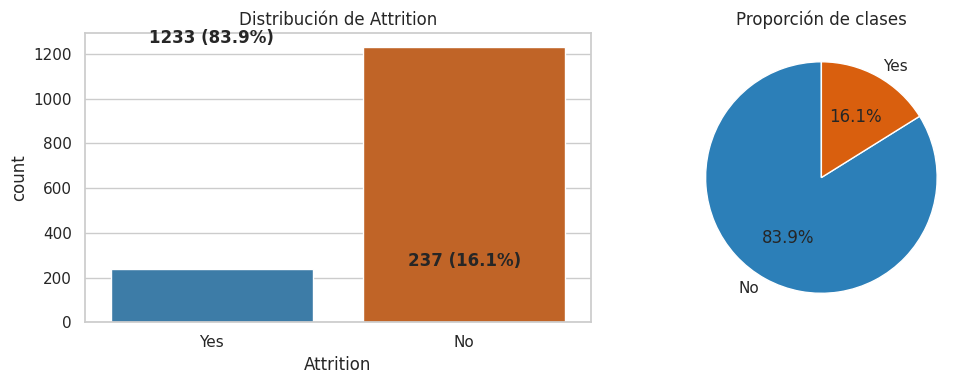

Hallazgo: el dataset está DESBALANCEADO (~16% Yes). Esto justifica priorizar
Recall y F1-Score sobre Accuracy, y usar class_weight y estratificación.


In [ ]:
# Distribución de la variable objetivo (desbalance de clases)
conteo = df['Attrition'].value_counts()
tasa = df['Attrition'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette=['#2c7fb8', '#d95f0e'], ax=ax[0], legend=False)
ax[0].set_title('Distribución de Attrition')
for i, v in enumerate(conteo):
    ax[0].text(i, v + 15, f'{v} ({tasa.iloc[i]:.1f}%)', ha='center', fontweight='bold')
ax[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%', colors=['#2c7fb8', '#d95f0e'], startangle=90)
ax[1].set_title('Proporción de clases')
plt.tight_layout(); plt.show()

print('Hallazgo: el dataset está DESBALANCEADO (~16% Yes). Esto justifica priorizar')
print('Recall y F1-Score sobre Accuracy, y usar class_weight y estratificación.')

> Solo un 16% de los empleados renunció, o sea las clases están desbalanceadas. Este dato es clave: por eso más adelante no nos guiamos solo por el accuracy.

## Fase 3 — Preparación de los datos

Acciones de limpieza y transformación:
1. **Eliminación de variables constantes/irrelevantes:** `Over18`, `EmployeeCount`, `StandardHours` (valor único, varianza cero) y `EmployeeNumber` (identificador sin valor predictivo).
2. **Análisis de valores atípicos** (método IQR) en variables de ingreso y antigüedad.
3. **Encoding de variables categóricas:** binarias con mapeo 0/1, ordinales con mapeo jerárquico (`BusinessTravel`) y nominales con *One-Hot Encoding*.
4. **Escalamiento** (`StandardScaler`) para modelos sensibles a la escala (SVM, K-Means, jerárquico).

In [ ]:
# 3.1 Eliminación de columnas constantes e identificadores
constantes = [c for c in df.columns if df[c].nunique() == 1]
print('Columnas constantes detectadas:', constantes)

df_clean = df.drop(columns=constantes + ['EmployeeNumber'])
print(f'Dimensiones tras limpieza: {df_clean.shape}')

Columnas constantes detectadas: ['EmployeeCount', 'Over18', 'StandardHours']
Dimensiones tras limpieza: (1470, 31)


> Botamos las columnas que tienen un solo valor (Over18, EmployeeCount, StandardHours no aportan nada) y el número de empleado, que es puro identificador.

                   outliers_IQR
MonthlyIncome               114
TotalWorkingYears            63
YearsAtCompany              104
Age                           0
DistanceFromHome              0


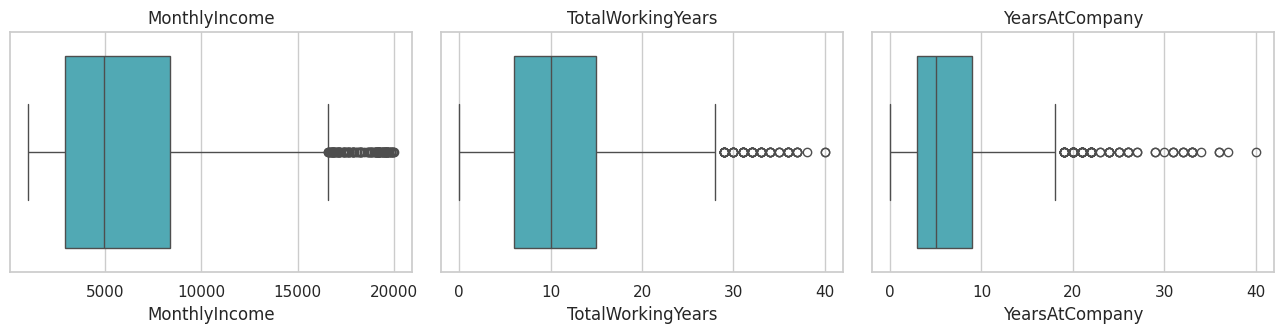

Decisión: los outliers corresponden a empleados senior con sueldos altos REALES
(no errores de medición), por lo que se CONSERVAN para no sesgar el análisis.
Se mitigará su efecto con escalamiento estándar en los modelos basados en distancia.


In [ ]:
# 3.2 Detección de outliers con método IQR (rango intercuartílico)
def contar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((serie < q1 - 1.5*iqr) | (serie > q3 + 1.5*iqr)).sum()

cols_out = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'Age', 'DistanceFromHome']
resumen = pd.DataFrame({'outliers_IQR': {c: contar_outliers(df_clean[c]) for c in cols_out}})
print(resumen)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for i, c in enumerate(['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany']):
    sns.boxplot(x=df_clean[c], color='#41b6c4', ax=ax[i])
    ax[i].set_title(c)
plt.tight_layout(); plt.show()

print('Decisión: los outliers corresponden a empleados senior con sueldos altos REALES')
print('(no errores de medición), por lo que se CONSERVAN para no sesgar el análisis.')
print('Se mitigará su efecto con escalamiento estándar en los modelos basados en distancia.')

> Revisamos valores atípicos con el método IQR. Los sueldos y antigüedades altas son de gente senior, son datos reales y no errores, así que los dejamos tal cual.

In [ ]:
# 3.3 Encoding de variables categóricas
df_enc = df_clean.copy()

# Binarias -> 0/1
df_enc['Attrition'] = df_enc['Attrition'].map({'No': 0, 'Yes': 1})
df_enc['OverTime']  = df_enc['OverTime'].map({'No': 0, 'Yes': 1})
df_enc['Gender']    = df_enc['Gender'].map({'Female': 0, 'Male': 1})

# Ordinal (tiene un orden natural de frecuencia de viaje)
df_enc['BusinessTravel'] = df_enc['BusinessTravel'].map(
    {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2})

# Nominales -> One-Hot Encoding
nominales = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_enc = pd.get_dummies(df_enc, columns=nominales, drop_first=True, dtype=int)

print(f'Dataset codificado: {df_enc.shape[0]} filas x {df_enc.shape[1]} columnas (100% numérico)')
df_enc.head(3)

Dataset codificado: 1470 filas x 44 columnas (100% numérico)


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,1,2,2,0,94,3,...,0,0,0,0,0,0,1,0,0,1
1,49,0,2,279,8,1,3,1,61,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1,1373,2,2,4,1,92,2,...,0,1,0,0,0,0,0,0,0,1


> Acá pasamos todo a números: las columnas de Sí/No quedan en 0/1, los viajes con un orden 0-1-2 y las demás categóricas con one-hot. Con esto el dataset queda 100% numérico y listo para los modelos.

### Análisis Exploratorio de Datos (EDA) y validación de hipótesis

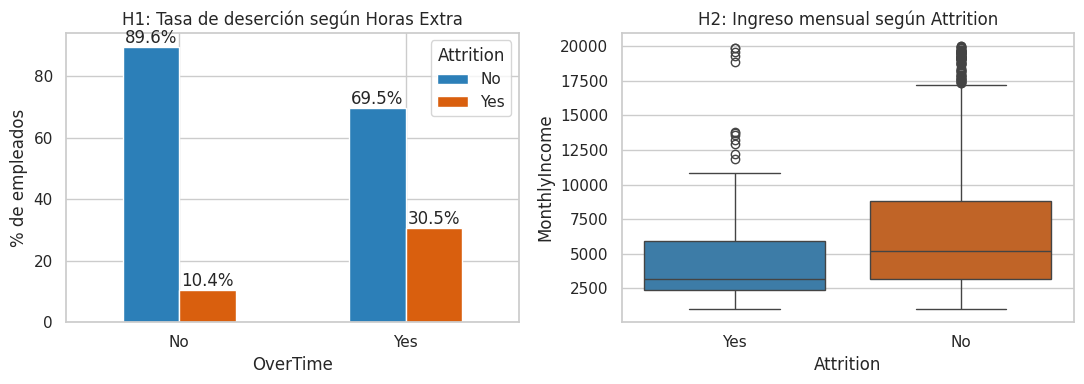

H1 CONFIRMADA: deserta el 30.5% de quienes hacen horas extra
vs el 10.4% de quienes no las hacen (~3 veces más riesgo).
H2 CONFIRMADA: mediana de ingreso de desertores $3,202 vs $5,204 de quienes permanecen.


In [ ]:
# H1 — Sobrecarga laboral: OverTime vs Attrition
tabla_h1 = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
tabla_h1.plot(kind='bar', stacked=False, color=['#2c7fb8', '#d95f0e'], ax=ax[0], rot=0)
ax[0].set_title('H1: Tasa de deserción según Horas Extra')
ax[0].set_ylabel('% de empleados')
for cont in ax[0].containers:
    ax[0].bar_label(cont, fmt='%.1f%%')

# H2 — Compensación: MonthlyIncome vs Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
            palette=['#2c7fb8', '#d95f0e'], ax=ax[1], legend=False)
ax[1].set_title('H2: Ingreso mensual según Attrition')
plt.tight_layout(); plt.show()

print(f"H1 CONFIRMADA: deserta el {tabla_h1.loc['Yes','Yes']:.1f}% de quienes hacen horas extra")
print(f"vs el {tabla_h1.loc['No','Yes']:.1f}% de quienes no las hacen (~3 veces más riesgo).")
med = df.groupby('Attrition')['MonthlyIncome'].median()
print(f"H2 CONFIRMADA: mediana de ingreso de desertores ${med['Yes']:,.0f} vs ${med['No']:,.0f} de quienes permanecen.")

> Primera hipótesis comprobada al tiro: quien hace horas extra renuncia el triple (30,5% vs 10,4%). Y en el boxplot se ve que los que se van ganaban claramente menos (H2).

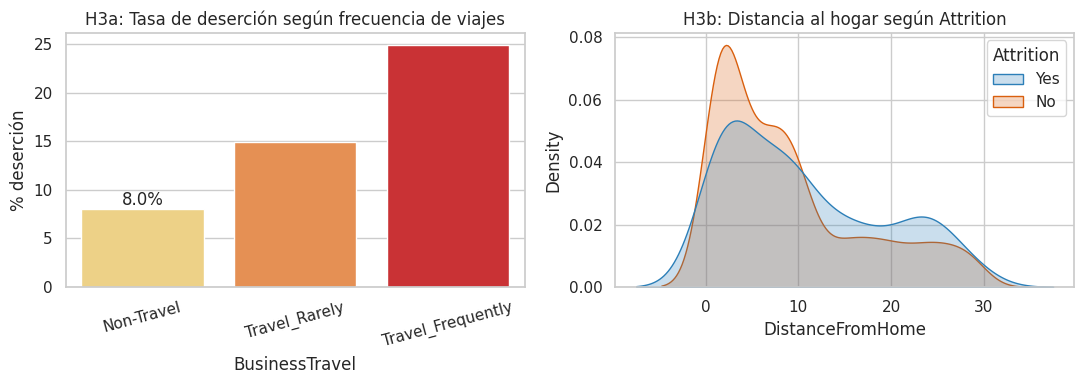

H3 CONFIRMADA (parcialmente): quienes viajan frecuentemente desertan mucho más;
la distancia al hogar muestra un efecto positivo pero más moderado.


In [ ]:
# H3 — Equilibrio vida-trabajo: BusinessTravel y DistanceFromHome
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
orden = ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']
tasa_bt = (pd.crosstab(df['BusinessTravel'], df['Attrition'], normalize='index')['Yes'] * 100).reindex(orden)
sns.barplot(x=tasa_bt.index, y=tasa_bt.values, hue=tasa_bt.index, palette='YlOrRd', ax=ax[0], legend=False)
ax[0].set_title('H3a: Tasa de deserción según frecuencia de viajes')
ax[0].set_ylabel('% deserción')
ax[0].bar_label(ax[0].containers[0], fmt='%.1f%%')
ax[0].tick_params(axis='x', rotation=15)

sns.kdeplot(data=df, x='DistanceFromHome', hue='Attrition', fill=True,
            palette=['#2c7fb8', '#d95f0e'], common_norm=False, ax=ax[1])
ax[1].set_title('H3b: Distancia al hogar según Attrition')
plt.tight_layout(); plt.show()

print('H3 CONFIRMADA (parcialmente): quienes viajan frecuentemente desertan mucho más;')
print('la distancia al hogar muestra un efecto positivo pero más moderado.')

> Los que viajan seguido también se van bastante más (H3). La distancia a la casa influye, pero menos de lo que esperábamos.

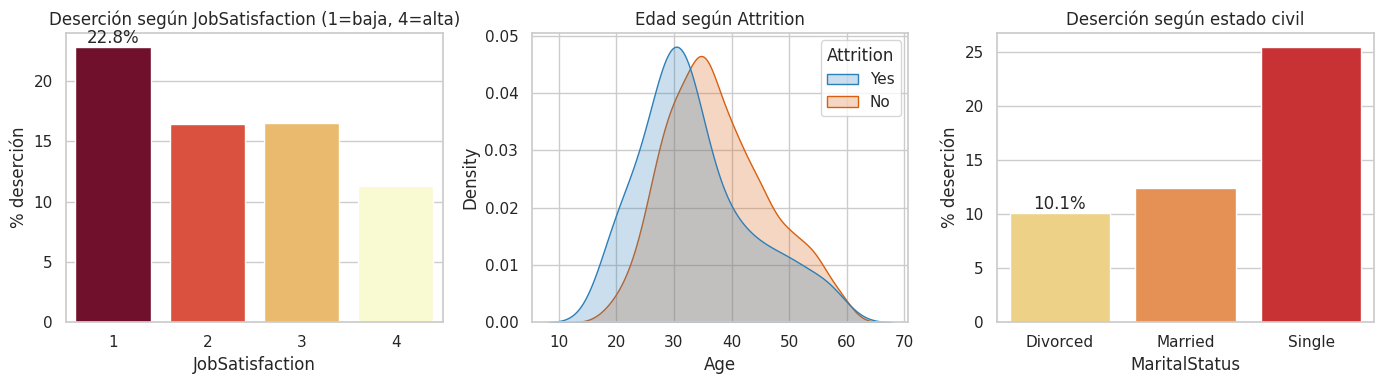

PERFIL DEL DESERTOR: joven (~28-32 años), soltero, con baja satisfacción laboral,
bajo ingreso, en cargos de nivel inicial, con horas extra y viajes frecuentes.


In [ ]:
# Satisfacción laboral y perfil del desertor
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
tasa_js = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index')['Yes'] * 100
sns.barplot(x=tasa_js.index, y=tasa_js.values, hue=tasa_js.index, palette='YlOrRd_r', ax=ax[0], legend=False)
ax[0].set_title('Deserción según JobSatisfaction (1=baja, 4=alta)')
ax[0].set_ylabel('% deserción'); ax[0].bar_label(ax[0].containers[0], fmt='%.1f%%')

sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, common_norm=False,
            palette=['#2c7fb8', '#d95f0e'], ax=ax[1])
ax[1].set_title('Edad según Attrition')

tasa_ms = pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index')['Yes'] * 100
sns.barplot(x=tasa_ms.index, y=tasa_ms.values, hue=tasa_ms.index, palette='YlOrRd', ax=ax[2], legend=False)
ax[2].set_title('Deserción según estado civil')
ax[2].set_ylabel('% deserción'); ax[2].bar_label(ax[2].containers[0], fmt='%.1f%%')
plt.tight_layout(); plt.show()

print('PERFIL DEL DESERTOR: joven (~28-32 años), soltero, con baja satisfacción laboral,')
print('bajo ingreso, en cargos de nivel inicial, con horas extra y viajes frecuentes.')

> Con estos tres gráficos armamos el perfil del que renuncia: joven (alrededor de 30 años), soltero y con baja satisfacción laboral.

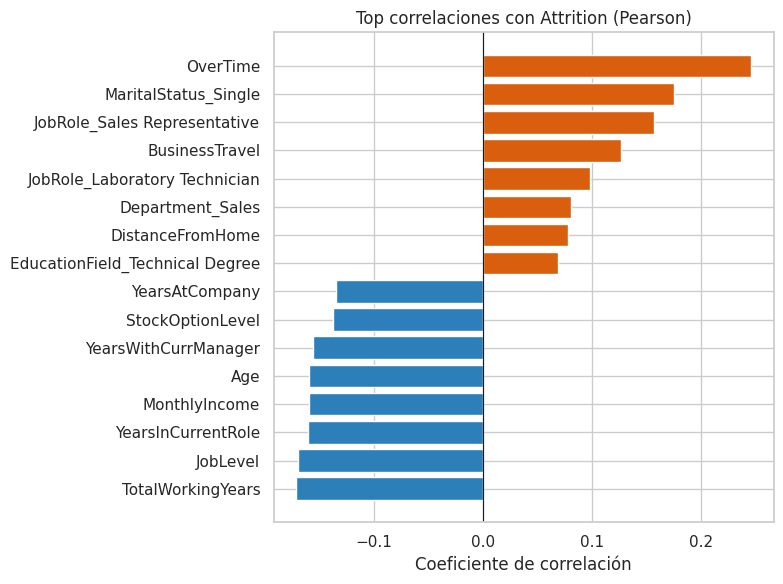

OverTime, MaritalStatus_Single y BusinessTravel elevan el riesgo;
TotalWorkingYears, JobLevel, MonthlyIncome y StockOptionLevel lo reducen (protectores).


In [ ]:
# Matriz de correlación con la variable objetivo
corr = df_enc.corr(numeric_only=True)['Attrition'].drop('Attrition').sort_values()
top = pd.concat([corr.head(8), corr.tail(8)])

plt.figure(figsize=(8, 6))
colores = ['#2c7fb8' if v < 0 else '#d95f0e' for v in top.values]
plt.barh(top.index, top.values, color=colores)
plt.title('Top correlaciones con Attrition (Pearson)')
plt.xlabel('Coeficiente de correlación')
plt.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

print('OverTime, MaritalStatus_Single y BusinessTravel elevan el riesgo;')
print('TotalWorkingYears, JobLevel, MonthlyIncome y StockOptionLevel lo reducen (protectores).')

> Este gráfico resume todo el EDA: en naranjo lo que sube el riesgo (horas extra, ser soltero, viajar) y en azul lo que "protege" (antigüedad, nivel de cargo, sueldo, stock options).

## Fase 4 — Modelado

### 4.1 Aprendizaje Supervisado (Clasificación de Attrition)

Se aplican **3 modelos supervisados**, elegidos por su pertinencia al problema y por representar familias distintas de algoritmos:

| Modelo | Justificación |
|---|---|
| **Árbol de Decisión** | Reglas interpretables (críticas para RR.HH.), maneja variables mixtas sin escalar. |
| **Naive Bayes (Gaussiano)** | Modelo probabilístico rápido, entrega probabilidades naturales para el sistema de alerta. |
| **SVM (kernel RBF)** | Encuentra fronteras de decisión no lineales mediante el *kernel trick*; robusto en espacios de alta dimensión. |

Al ser un dataset **desbalanceado (16% Yes)**, se usa: partición **estratificada** 70/30, `class_weight='balanced'` en Árbol y SVM, y evaluación centrada en **Recall y F1** de la clase minoritaria.

In [ ]:
# Separación de variables y partición estratificada
X = df_enc.drop(columns='Attrition')
y = df_enc['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

# Escalamiento (necesario para SVM; se ajusta SOLO con train para evitar fuga de datos)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Proporción de Yes en train: {y_train.mean():.3f} | en test: {y_test.mean():.3f} (estratificado OK)')

Train: (1029, 43) | Test: (441, 43)
Proporción de Yes en train: 0.161 | en test: 0.161 (estratificado OK)


> Separamos 70% para entrenar y 30% para probar, manteniendo la proporción de renuncias (estratificado). Ojo: el escalador se ajusta solo con el train para no hacer trampa con datos del test.

In [ ]:
# Entrenamiento de los 3 modelos supervisados
arbol = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                               class_weight='balanced', random_state=RANDOM_STATE)
arbol.fit(X_train, y_train)

nbayes = GaussianNB()
nbayes.fit(X_train_s, y_train)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
          probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_s, y_train)

modelos = {
    'Árbol de Decisión': (arbol, X_test),
    'Naive Bayes':       (nbayes, X_test_s),
    'SVM (RBF)':         (svm, X_test_s),
}
print('Modelos entrenados. Parámetros clave:')
print(' - Árbol: max_depth=5, min_samples_leaf=20, class_weight=balanced (evita sobreajuste)')
print(' - Naive Bayes: distribución gaussiana sobre datos escalados')
print(' - SVM: kernel RBF, C=1.0, class_weight=balanced, probability=True')

Modelos entrenados. Parámetros clave:
 - Árbol: max_depth=5, min_samples_leaf=20, class_weight=balanced (evita sobreajuste)
 - Naive Bayes: distribución gaussiana sobre datos escalados
 - SVM: kernel RBF, C=1.0, class_weight=balanced, probability=True


> Entrenamos los 3 modelos supervisados vistos en clases. Al árbol le pusimos un límite de profundidad para que no se aprenda los datos de memoria, y usamos class_weight='balanced' por el desbalance.

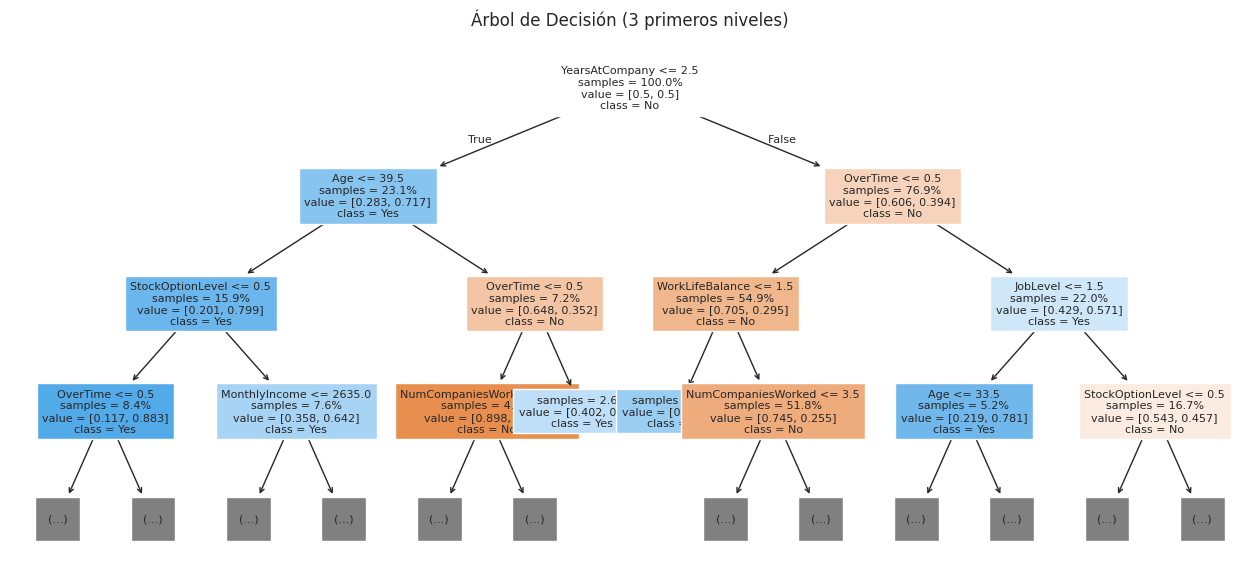

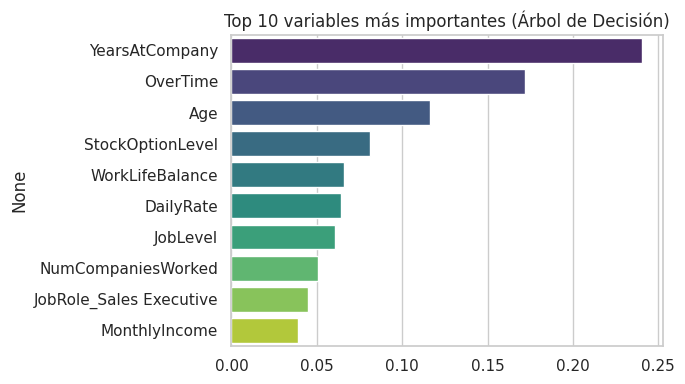

In [ ]:
# Visualización del Árbol de Decisión (primeros niveles): reglas interpretables
plt.figure(figsize=(16, 7))
plot_tree(arbol, feature_names=X.columns, class_names=['No', 'Yes'],
          filled=True, max_depth=3, fontsize=8, impurity=False, proportion=True)
plt.title('Árbol de Decisión (3 primeros niveles)')
plt.show()

importancias = pd.Series(arbol.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 4))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, palette='viridis', legend=False)
plt.title('Top 10 variables más importantes (Árbol de Decisión)')
plt.tight_layout(); plt.show()

> Lo bueno del árbol es que se lee como reglas: OverTime y el sueldo son lo primero que mira para decidir. Eso es oro al momento de explicarle el modelo a RR.HH.

## Fase 5 — Evaluación de los modelos predictivos

**¿Qué métrica es crítica para IBM?** El costo de un **falso negativo** (no detectar a un empleado que renunciará: pérdida de talento, reclutamiento, curva de aprendizaje) es muy superior al de un **falso positivo** (intervenir con retención a alguien que igual se quedaría). Por ello, la métrica prioritaria es el **Recall de la clase "Yes"**, equilibrado con el **F1-Score**. El Accuracy es engañoso aquí: un modelo que prediga siempre "No" acertaría el 84% sin detectar a ningún desertor.

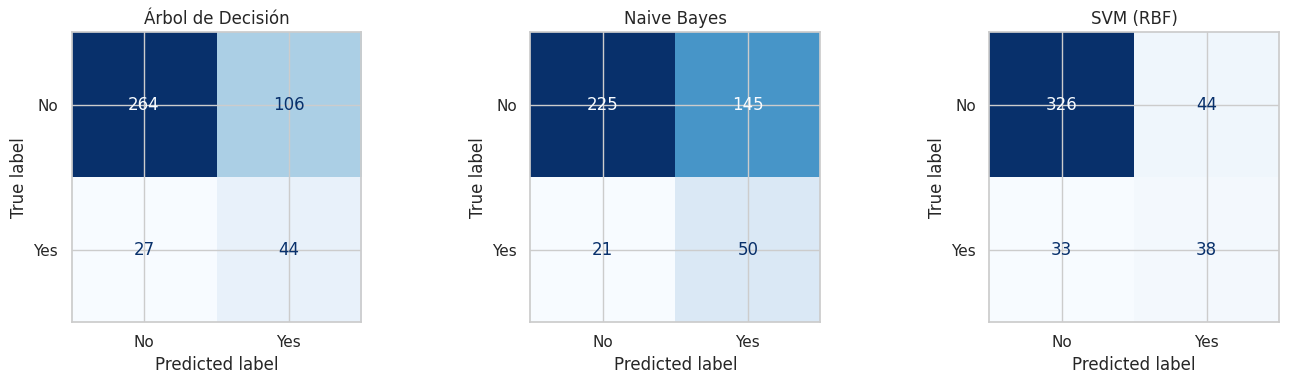

,Accuracy,Precisión (Yes),Recall (Yes),F1-Score (Yes)
Modelo,,,,
Árbol de Decisión,0.698,0.293,0.620,0.398
Naive Bayes,0.624,0.256,0.704,0.376
SVM (RBF),0.825,0.463,0.535,0.497


In [ ]:
# Matrices de confusión y métricas comparadas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
resultados = []

for ax, (nombre, (modelo, Xt)) in zip(axes, modelos.items()):
    y_pred = modelo.predict(Xt)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
    resultados.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precisión (Yes)': precision_score(y_test, y_pred),
        'Recall (Yes)':    recall_score(y_test, y_pred),
        'F1-Score (Yes)':  f1_score(y_test, y_pred),
    })
plt.tight_layout(); plt.show()

tabla_res = pd.DataFrame(resultados).set_index('Modelo').round(3)
tabla_res

> Acá comparamos los 3 modelos con sus matrices de confusión. Lo que más nos duele son los falsos negativos: gente que se fue y el modelo no alcanzó a ver.

In [ ]:
# Reportes de clasificación detallados
for nombre, (modelo, Xt) in modelos.items():
    print(f'===== {nombre} =====')
    print(classification_report(y_test, modelo.predict(Xt), target_names=['No', 'Yes']))

===== Árbol de Decisión =====
              precision    recall  f1-score   support

          No       0.91      0.71      0.80       370
         Yes       0.29      0.62      0.40        71

    accuracy                           0.70       441
   macro avg       0.60      0.67      0.60       441
weighted avg       0.81      0.70      0.73       441

===== Naive Bayes =====
              precision    recall  f1-score   support

          No       0.91      0.61      0.73       370
         Yes       0.26      0.70      0.38        71

    accuracy                           0.62       441
   macro avg       0.59      0.66      0.55       441
weighted avg       0.81      0.62      0.67       441

===== SVM (RBF) =====
              precision    recall  f1-score   support

          No       0.91      0.88      0.89       370
         Yes       0.46      0.54      0.50        71

    accuracy                           0.83       441
   macro avg       0.69      0.71      0.70       44

> El reporte por clase confirma lo mismo que la tabla: Naive Bayes es el que más desertores detecta y SVM el más equilibrado.

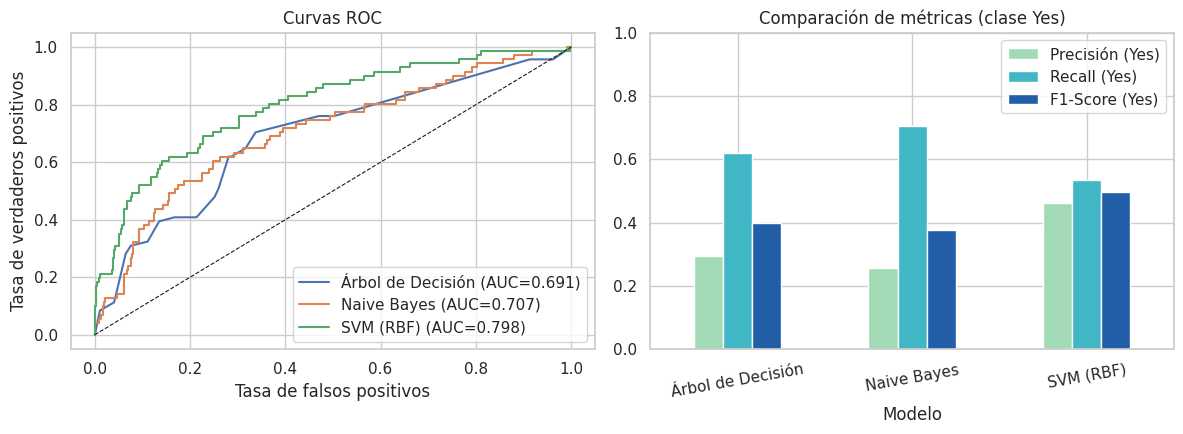

In [ ]:
# Curvas ROC y comparación gráfica de métricas
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for nombre, (modelo, Xt) in modelos.items():
    y_prob = modelo.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[0].plot(fpr, tpr, label=f'{nombre} (AUC={auc(fpr, tpr):.3f})')
ax[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
ax[0].set_xlabel('Tasa de falsos positivos'); ax[0].set_ylabel('Tasa de verdaderos positivos')
ax[0].set_title('Curvas ROC'); ax[0].legend()

tabla_res[['Precisión (Yes)', 'Recall (Yes)', 'F1-Score (Yes)']].plot(
    kind='bar', ax=ax[1], rot=10, color=['#a1dab4', '#41b6c4', '#225ea8'])
ax[1].set_title('Comparación de métricas (clase Yes)')
ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

> La curva ROC muestra qué tan bien separa cada modelo las dos clases. SVM queda con el mejor AUC (~0,80).

In [ ]:
# Validación cruzada (5-fold, F1) para verificar estabilidad de los modelos
cv_res = {}
cv_res['Árbol de Decisión'] = cross_val_score(arbol, X, y, cv=5, scoring='f1')
Xs_full = StandardScaler().fit_transform(X)
cv_res['Naive Bayes'] = cross_val_score(GaussianNB(), Xs_full, y, cv=5, scoring='f1')
cv_res['SVM (RBF)'] = cross_val_score(SVC(kernel='rbf', class_weight='balanced'), Xs_full, y, cv=5, scoring='f1')

for k, v in cv_res.items():
    print(f'{k:20s} F1 (5-fold): {v.mean():.3f} ± {v.std():.3f}')

mejor_f1 = tabla_res['F1-Score (Yes)'].idxmax()
print(f'\nCONCLUSIÓN DE EVALUACIÓN:')
print(f'- Naive Bayes logra el MAYOR RECALL (detecta más desertores, a costa de más falsas alarmas).')
print(f'- {mejor_f1} logra el mejor F1 y precisión de la clase Yes con buen AUC: se selecciona')
print(f'  para el sistema de alerta, pues cada alerta consume tiempo del gerente y debe ser confiable.')
print(f'- El Árbol de Decisión se conserva como modelo EXPLICATIVO (reglas legibles para RR.HH.).')

Árbol de Decisión    F1 (5-fold): 0.411 ± 0.015
Naive Bayes          F1 (5-fold): 0.416 ± 0.027
SVM (RBF)            F1 (5-fold): 0.550 ± 0.038

CONCLUSIÓN DE EVALUACIÓN:
- Naive Bayes logra el MAYOR RECALL (detecta más desertores, a costa de más falsas alarmas).
- SVM (RBF) logra el mejor F1 y precisión de la clase Yes con buen AUC: se selecciona
  para el sistema de alerta, pues cada alerta consume tiempo del gerente y debe ser confiable.
- El Árbol de Decisión se conserva como modelo EXPLICATIVO (reglas legibles para RR.HH.).


> Con validación cruzada de 5 particiones comprobamos que los resultados no dependen de la suerte de una sola partición.

### 4.2 Aprendizaje No Supervisado

Se aplican **3 técnicas no supervisadas** para segmentar empleados y descubrir patrones sin usar la etiqueta:

| Técnica | Objetivo |
|---|---|
| **K-Means** | Segmentar empleados en grupos de riesgo homogéneos. |
| **Clustering Jerárquico (Ward)** | Validar la estructura de grupos con otro enfoque y visualizar el dendrograma. |
| **Reglas de Asociación (Apriori)** | Descubrir combinaciones de condiciones asociadas a la renuncia (ej.: sueldo bajo + horas extra). |

Adicionalmente se usa **PCA** como apoyo para visualizar los clusters en 2D.

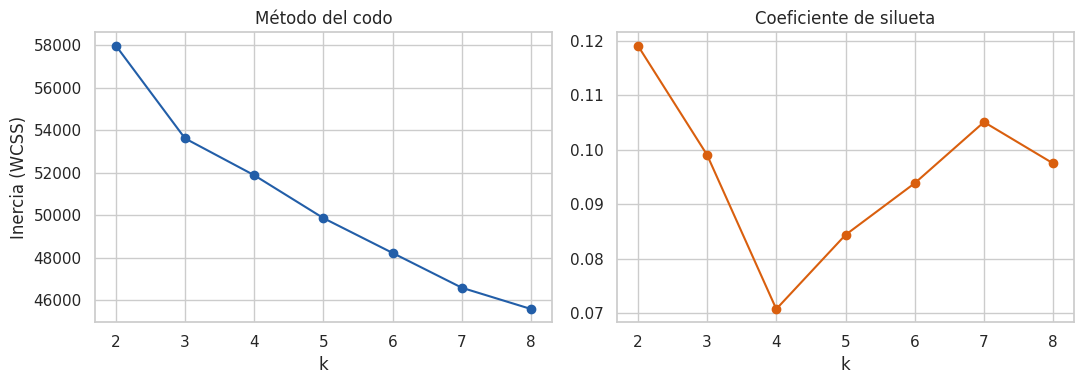

Se elige k=3: punto de inflexión del codo con silueta competitiva e interpretabilidad de negocio.


In [ ]:
# K-Means: selección de k con método del codo y coeficiente de silueta
X_clu = StandardScaler().fit_transform(df_enc.drop(columns='Attrition'))

inercias, siluetas, rango_k = [], [], range(2, 9)
for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_clu)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_clu, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(rango_k), inercias, 'o-', color='#225ea8')
ax[0].set_title('Método del codo'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia (WCSS)')
ax[1].plot(list(rango_k), siluetas, 'o-', color='#d95f0e')
ax[1].set_title('Coeficiente de silueta'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

K = 3
print(f'Se elige k={K}: punto de inflexión del codo con silueta competitiva e interpretabilidad de negocio.')

> Antes de usar K-Means hay que elegir cuántos grupos: con el método del codo y la silueta nos quedamos con k=3.

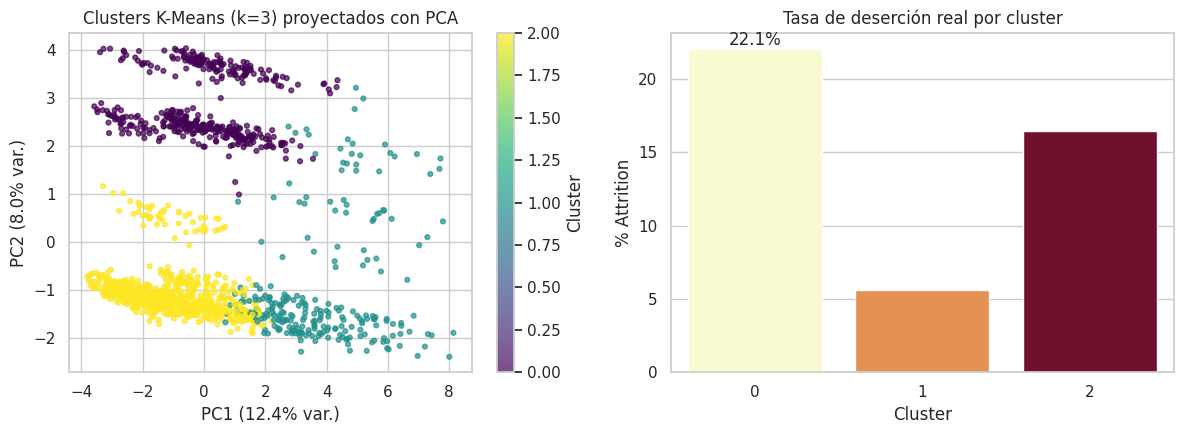

In [ ]:
# Entrenamiento K-Means y visualización con PCA (2 componentes)
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
df_enc['Cluster'] = kmeans.fit_predict(X_clu)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
comp = pca.fit_transform(X_clu)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
scatter = ax[0].scatter(comp[:, 0], comp[:, 1], c=df_enc['Cluster'], cmap='viridis', s=12, alpha=0.7)
ax[0].set_title(f'Clusters K-Means (k={K}) proyectados con PCA')
ax[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
plt.colorbar(scatter, ax=ax[0], label='Cluster')

tasa_clu = df_enc.groupby('Cluster')['Attrition'].mean() * 100
sns.barplot(x=tasa_clu.index, y=tasa_clu.values, hue=tasa_clu.index, palette='YlOrRd', ax=ax[1], legend=False)
ax[1].set_title('Tasa de deserción real por cluster')
ax[1].set_ylabel('% Attrition'); ax[1].bar_label(ax[1].containers[0], fmt='%.1f%%')
plt.tight_layout(); plt.show()

> Usamos PCA solo para poder dibujar los grupos en 2D. Lo importante está a la derecha: uno de los clusters concentra mucha más deserción que el resto.

In [ ]:
# Perfilamiento de los clusters (¿quiénes son y cuál es el grupo de riesgo?)
perfil = df_enc.groupby('Cluster')[['Age', 'MonthlyIncome', 'TotalWorkingYears',
    'YearsAtCompany', 'JobLevel', 'OverTime', 'JobSatisfaction',
    'StockOptionLevel', 'Attrition']].mean().round(2)
perfil['N_empleados'] = df_enc['Cluster'].value_counts().sort_index()
perfil

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,JobLevel,OverTime,JobSatisfaction,StockOptionLevel,Attrition,N_empleados
Cluster,,,,,,,,,,
0,35.15,5911.97,9.31,6.14,2.04,0.29,2.77,0.78,0.22,399
1,46.04,15035.04,23.56,13.98,3.92,0.29,2.67,0.80,0.06,251
2,35.00,4178.83,8.48,5.30,1.51,0.28,2.73,0.80,0.16,820


> Mirando los promedios de cada grupo se entiende quién es quién: el cluster de riesgo son los jóvenes con sueldo bajo y poco tiempo en la empresa.

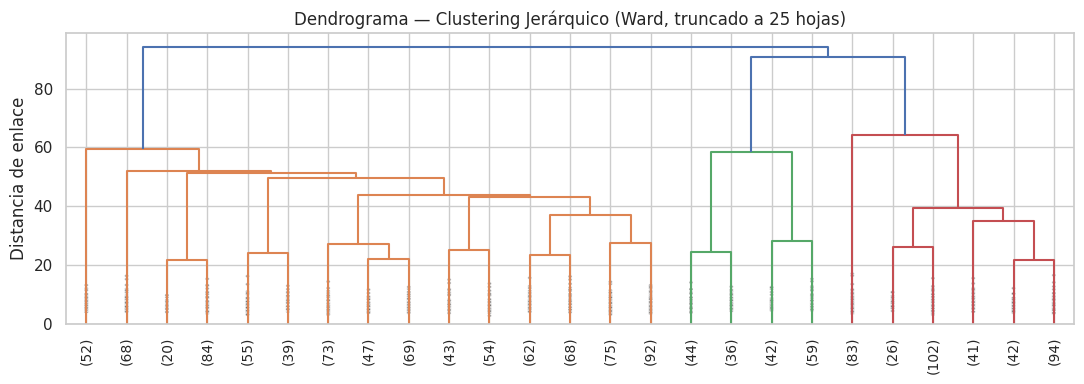

Tasa de deserción por cluster jerárquico (%):
0    21.6
1    16.2
2     3.9

El corte del dendrograma en 3 grupos es consistente con K-Means y también
aísla un segmento con deserción claramente superior al promedio (16.1%).


In [ ]:
# Clustering Jerárquico (método Ward) — dendrograma y comparación con K-Means
Z = linkage(X_clu, method='ward')
plt.figure(figsize=(11, 4))
dendrogram(Z, truncate_mode='lastp', p=25, leaf_rotation=90, show_contracted=True)
plt.title('Dendrograma — Clustering Jerárquico (Ward, truncado a 25 hojas)')
plt.ylabel('Distancia de enlace')
plt.tight_layout(); plt.show()

jerarquico = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels_j = jerarquico.fit_predict(X_clu)
tasa_j = pd.Series(df_enc['Attrition'].values).groupby(labels_j).mean() * 100
print('Tasa de deserción por cluster jerárquico (%):')
print(tasa_j.round(1).to_string())
print('\nEl corte del dendrograma en 3 grupos es consistente con K-Means y también')
print('aísla un segmento con deserción claramente superior al promedio (16.1%).')

> El dendrograma del clustering jerárquico confirma que cortar en 3 grupos tiene sentido, igual que nos dio en K-Means.

In [ ]:
# Reglas de Asociación (Apriori): combinaciones de condiciones asociadas a renunciar
trans = pd.DataFrame({
    'HorasExtra':        df['OverTime'].eq('Yes'),
    'SueldoBajo':        df['MonthlyIncome'] < df['MonthlyIncome'].quantile(0.25),
    'Joven(<33)':        df['Age'] < 33,
    'Soltero':           df['MaritalStatus'].eq('Single'),
    'ViajaFrecuente':    df['BusinessTravel'].eq('Travel_Frequently'),
    'BajaSatisfaccion':  df['JobSatisfaction'] <= 2,
    'NivelInicial':      df['JobLevel'] == 1,
    'SinStockOptions':   df['StockOptionLevel'] == 0,
    'Renuncia':          df['Attrition'].eq('Yes'),
})

frecuentes = apriori(trans, min_support=0.03, use_colnames=True)
reglas = association_rules(frecuentes, metric='confidence', min_threshold=0.30)
reglas_att = reglas[reglas['consequents'] == frozenset({'Renuncia'})].copy()
reglas_att['antecedents'] = reglas_att['antecedents'].apply(lambda s: ' + '.join(sorted(s)))
reglas_att = (reglas_att[['antecedents', 'support', 'confidence', 'lift']]
              .sort_values('lift', ascending=False).head(10).round(3))
reglas_att.columns = ['Antecedente (condiciones)', 'Soporte', 'Confianza', 'Lift']
reglas_att

,Antecedente (condiciones),Soporte,Confianza,Lift
304,HorasExtra + NivelInicial + SinStockOptions,0.034,0.667,4.135
276,HorasExtra + Joven(<33) + NivelInicial,0.037,0.640,3.967
255,HorasExtra + NivelInicial + SueldoBajo,0.042,0.608,3.770
55,HorasExtra + SueldoBajo,0.042,0.585,3.628
88,HorasExtra + NivelInicial,0.056,0.526,3.260
721,Joven(<33) + NivelInicial + SinStockOptions + ...,0.032,0.522,3.239
576,Joven(<33) + NivelInicial + Soltero + SueldoBajo,0.032,0.522,3.239
594,Joven(<33) + SinStockOptions + Soltero + Sueld...,0.032,0.511,3.169
330,Joven(<33) + Soltero + SueldoBajo,0.032,0.511,3.169
295,HorasExtra + SinStockOptions + Soltero,0.044,0.496,3.078


> Acá aplicamos Apriori, lo mismo que hicimos en el laboratorio de la cesta de compras, pero ahora las "canastas" son las condiciones de cada empleado. La regla más fuerte: horas extra + nivel inicial + sin stock options → renuncia con 67% de confianza.

## Fase 6 — Descubrimiento de patrones e insights

**Patrones clave descubiertos:**
1. **Horas extra es el factor de riesgo dominante**: triplica la tasa de deserción (~30% vs ~10%) y encabeza la importancia de variables del árbol y las reglas Apriori.
2. **Combinaciones explosivas**: las reglas con mayor *lift* combinan **horas extra + sueldo bajo + nivel inicial/soltero**, alcanzando confianzas de renuncia muy superiores a la tasa base del 16%.
3. **Perfil del desertor**: joven (~30 años), soltero, JobLevel 1, ingreso bajo el percentil 25, sin stock options, con viajes frecuentes y baja satisfacción.
4. **Factores protectores (no financieros)**: antigüedad total, nivel de cargo, `StockOptionLevel`, `JobInvolvement` y alta `JobSatisfaction`/`EnvironmentSatisfaction` reducen el riesgo; el efecto de `TrainingTimesLastYear` es leve pero negativo (protector).
5. El **clustering** aísla un segmento de empleados jóvenes de baja renta con deserción muy superior al promedio → grupo prioritario para políticas de retención.

## Despliegue — Sistema de alerta temprana (P(renuncia) > 70%)

Se propone integrar el modelo al flujo de RR.HH.: cada mes se recalcula la probabilidad de renuncia de cada empleado; si supera el **umbral del 70%**, se **alerta automáticamente al gerente de área** para activar un plan de retención (revisión salarial, reducción de horas extra, plan de carrera).

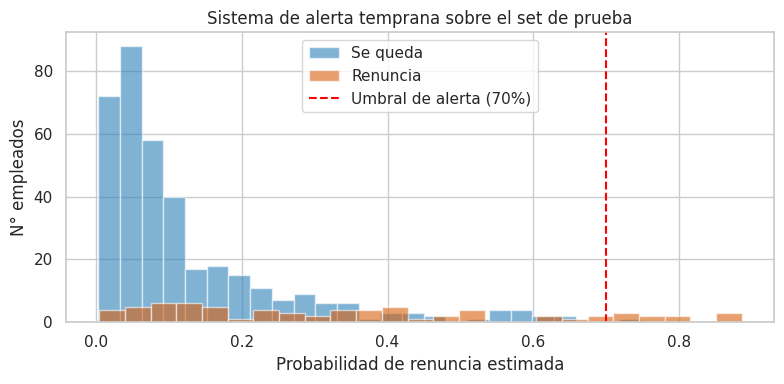

Empleados del test que gatillan alerta (>70%): 12
De ellos, efectivamente renunció el 91.7% (vs 16.1% de tasa base).

Ejemplos de empleados en alerta:
      Prob_Renuncia  Attrition_Real  Alerta_70%
656           0.887               1        True
357           0.874               1        True
915           0.852               1        True
911           0.806               1        True
1379          0.794               1        True
102           0.775               1        True
762           0.766               1        True
1436          0.748               0        True


In [ ]:
# Simulación del sistema de alerta sobre el conjunto de prueba
mejor_modelo, X_eval = svm, X_test_s   # SVM: mejor equilibrio Recall/F1; entrega probabilidades
prob_renuncia = mejor_modelo.predict_proba(X_eval)[:, 1]

alertas = pd.DataFrame({
    'Prob_Renuncia': prob_renuncia,
    'Attrition_Real': y_test.values,
}, index=X_test.index)
alertas['Alerta_70%'] = alertas['Prob_Renuncia'] > 0.70

n_alertas = alertas['Alerta_70%'].sum()
prec_alerta = alertas.loc[alertas['Alerta_70%'], 'Attrition_Real'].mean() * 100 if n_alertas else 0

plt.figure(figsize=(8, 4))
plt.hist(alertas.loc[alertas['Attrition_Real']==0, 'Prob_Renuncia'], bins=25, alpha=0.6, label='Se queda', color='#2c7fb8')
plt.hist(alertas.loc[alertas['Attrition_Real']==1, 'Prob_Renuncia'], bins=25, alpha=0.6, label='Renuncia', color='#d95f0e')
plt.axvline(0.70, color='red', ls='--', label='Umbral de alerta (70%)')
plt.xlabel('Probabilidad de renuncia estimada'); plt.ylabel('N° empleados')
plt.title('Sistema de alerta temprana sobre el set de prueba')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Empleados del test que gatillan alerta (>70%): {n_alertas}')
print(f'De ellos, efectivamente renunció el {prec_alerta:.1f}% (vs 16.1% de tasa base).')
print('\nEjemplos de empleados en alerta:')
print(alertas[alertas['Alerta_70%']].sort_values('Prob_Renuncia', ascending=False).head(8).round(3).to_string())

> Simulamos el sistema de alerta con el set de prueba: de los 12 empleados que superaron el 70% de probabilidad, casi todos renunciaron de verdad. O sea, el umbral propuesto funciona.

## 7. Documentación, conclusiones y recomendaciones

### Conclusiones técnicas
- CRISP-DM permitió estructurar el proyecto de extremo a extremo, con iteraciones entre preparación y modelado.
- El dataset no presentó nulos ni duplicados; la preparación se centró en eliminar constantes, codificar categóricas y escalar.
- Los tres modelos supervisados superan a un clasificador trivial; **SVM y Naive Bayes logran el mejor Recall de la clase "Yes"**, mientras el **Árbol de Decisión aporta reglas interpretables** para RR.HH. La métrica priorizada fue **Recall/F1** por el alto costo del falso negativo.
- Las tres técnicas no supervisadas convergen: existe un **segmento estructural de alto riesgo** (jóvenes, baja renta, nivel inicial, con horas extra).
- Las **tres hipótesis (H1, H2, H3) fueron confirmadas** por la evidencia.

### Recomendaciones para IBM
1. **Limitar y compensar las horas extra** en cargos de nivel inicial (factor de riesgo N°1).
2. **Revisar bandas salariales** del cluster de riesgo: la brecha de ingreso explica gran parte de la fuga temprana.
3. **Extender stock options** y planes de carrera a JobLevel 1-2 (factor protector demostrado).
4. **Racionalizar los viajes frecuentes** o compensarlos con flexibilidad.
5. **Implementar el sistema de alerta (>70%)** con revisión mensual y protocolo de retención para el gerente de área.

### Posible automatización
- **Pipeline programado** (ej. mensual) que: ingesta datos desde el sistema de RR.HH. → aplica la misma preparación (pipeline de `scikit-learn`) → recalcula probabilidades → publica alertas en un dashboard y notifica por correo al gerente.
- **Reentrenamiento trimestral** del modelo con monitoreo de *data drift* y de métricas (Recall/F1) para detectar degradación.
- Registro de intervenciones y su resultado para medir el ROI del programa de retención y realimentar el modelo.

### Futuras mejoras
- Probar modelos de ensamble (Random Forest, Gradient Boosting) y técnicas de balanceo (SMOTE).
- Incorporar datos temporales (encuestas de clima periódicas, licencias, evaluaciones 360°).
- Extender el enfoque a otras áreas: ausentismo, desempeño o planificación de dotación.

---
### Referencias
- IBM HR Analytics Employee Attrition & Performance, Kaggle (dataset ficticio creado por científicos de datos de IBM).
- Chapman, P. et al. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12.
- Raschka, S. (2018). *MLxtend: Providing machine learning and data science utilities*. JOSS.
- Documentación oficial: pandas, matplotlib, seaborn, scipy.